# 红利低波原始指数编制

本 notebook 只读取本地数据并一键计算年度调仓指数。请先按需运行 `download.ipynb`。

In [1]:
import os
import sys
from pathlib import Path

project_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').exists())
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from pyquant import load_config, load_dataset
from strategies.cross_sectional.dividend_low_vol.components import calculate_dividend_low_vol_rebalanced_index

plt.rcParams['font.family'] = 'STHeiti'
plt.rcParams['axes.unicode_minus'] = False

## 配置与本地数据

In [3]:
strategy_dir = project_root / 'strategies/cross_sectional/dividend_low_vol'
config = load_config(strategy_dir / 'config.yaml')
start_date = pd.Timestamp(config['data']['start_date'])
end_date = pd.Timestamp(config['data']['end_date'])
lookback_date = start_date - pd.DateOffset(years=3)

price = load_dataset('stock_daily', start=lookback_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))
dividends = load_dataset('dividend')
dividend_queries = load_dataset('dividend_queries')
shares = load_dataset('stock_profit_quarterly')
official_index = load_dataset(
    'csindex_daily',
    start=start_date.strftime('%Y-%m-%d'),
    end=end_date.strftime('%Y-%m-%d'),
    symbols=['H30269', 'H20269'],
).pivot(index='date', columns='symbol', values='close')
missing_codes = {'H30269', 'H20269'} - set(official_index)
if missing_codes:
    raise ValueError(f'Missing official CSI index codes: {sorted(missing_codes)}')
official_index = official_index[['H30269', 'H20269']].rename(
    columns={'H30269': '中证红利低波', 'H20269': '中证红利低波全收益'}
)

## 年度调仓指数

In [4]:
index, constituents = calculate_dividend_low_vol_rebalanced_index(
    price,
    dividends,
    dividend_queries,
    shares,
    start_date,
    end_date,
    config,
)
index.tail()

,price_return,total_return,dividend_cash,price_index,total_return_index
date,,,,,
2023-06-12,-0.008286,-0.008286,0.000000,1.779899,3.756433
2023-06-13,-0.000100,-0.000100,0.000000,1.779722,3.756058
2023-06-14,-0.008799,-0.005223,0.004054,1.764061,3.736441
2023-06-15,-0.000630,0.003696,0.004860,1.762950,3.750250
2023-06-16,-0.002384,-0.002384,0.000000,1.758747,3.741308


## 调仓成分

`constituents` 以 `(effective_date, symbol)` 为索引，包含每期选样指标和权重。

In [5]:
constituents.loc[constituents.index.get_level_values('effective_date') == constituents.index.get_level_values('effective_date').max()]

as_of_date price_date  avg_market_cap_240d  \
effective_date symbol                                                 
2022-12-12     sh.600015 2022-12-09 2022-12-09         8.163179e+10   
               sh.600019 2022-12-09 2022-12-09         1.388579e+11   
               sh.600023 2022-12-09 2022-12-09         4.817584e+10   
               sh.600028 2022-12-09 2022-12-09         5.163334e+11   
               sh.600057 2022-12-09 2022-12-09         1.958338e+10   
               sh.600177 2022-12-09 2022-12-09         3.063360e+10   
               sh.600273 2022-12-09 2022-12-09         1.451160e+10   
               sh.600282 2022-12-09 2022-12-09         2.069758e+10   
               sh.600373 2022-12-09 2022-12-09         1.388268e+10   
               sh.600398 2022-12-09 2022-12-09         2.220619e+10   
               sh.600449 2022-12-09 2022-12-09         5.940859e+09   
               sh.600585 2022-12-09 2022-12-09         1.858775e+11   
               sh.600755 2022-12-09 2022-12-09         1.537867e+10   
               sh.600757 2022-12-09 2022-12-09         6.713964e+09   
               sh.600782 2022-12-09 2022-12-09         1.612909e+10   
               sh.600810 2022-12-09 2022-12-09         1.004948e+10   
               sh.600873 2022-12-09 2022-12-09         2.920395e+10   
               sh.600901 2022-12-09 2022-12-09         1.529483e+10   
               sh.600919 2022-12-09 2022-12-09         1.022274e+11   
               sh.600971 2022-12-09 2022-12-09         9.093337e+09   
               sh.600985 2022-12-09 2022-12-09         2.443980e+09   
               sh.600987 2022-12-09 2022-12-09         3.773874e+09   
               sh.601000 2022-12-09 2022-12-09         5.529239e+09   
               sh.601006 2022-12-09 2022-12-09         9.797092e+10   
               sh.601009 2022-12-09 2022-12-09         3.081567e+10   
               sh.601088 2022-12-09 2022-12-09         5.743982e+11   
               sh.601098 2022-12-09 2022-12-09         1.730618e+10   
               sh.601166 2022-12-09 2022-12-09         3.617229e+11   
               sh.601169 2022-12-09 2022-12-09         3.838410e+10   
               sh.601229 2022-12-09 2022-12-09                  NaN   
               sh.601288 2022-12-09 2022-12-09         9.531489e+11   
               sh.601298 2022-12-09 2022-12-09                  NaN   
               sh.601328 2022-12-09 2022-12-09         3.538248e+11   
               sh.601398 2022-12-09 2022-12-09         1.593489e+12   
               sh.601928 2022-12-09 2022-12-09         1.950189e+10   
               sh.601939 2022-12-09 2022-12-09         1.452928e+12   
               sh.601988 2022-12-09 2022-12-09         8.739222e+11   
               sh.601998 2022-12-09 2022-12-09         2.181732e+11   
               sh.603013 2022-12-09 2022-12-09                  NaN   
               sz.000030 2022-12-09 2022-12-09         7.233786e+09   
               sz.000401 2022-12-09 2022-12-09         1.391817e+10   
               sz.000581 2022-12-09 2022-12-09         2.006536e+10   
               sz.000651 2022-12-09 2022-12-09         1.006981e+11   
               sz.000719 2022-12-09 2022-12-09         3.381485e+09   
               sz.000789 2022-12-09 2022-12-09         4.462856e+09   
               sz.000830 2022-12-09 2022-12-09         2.268401e+10   
               sz.000989 2022-12-09 2022-12-09         2.752836e+09   
               sz.002601 2022-12-09 2022-12-09         3.995809e+09   
               sz.002807 2022-12-09 2022-12-09                  NaN   
               sz.002818 2022-12-09 2022-12-09                  NaN   

                          avg_amount_240d  dividend_yield_ttm  payout_ratio  \
effective_date symbol                                                         
2022-12-12     sh.600015     1.304897e+08            0.121170      0.418601   
               sh.600019     5.145313e+08            0.138946      1.581245   
               s

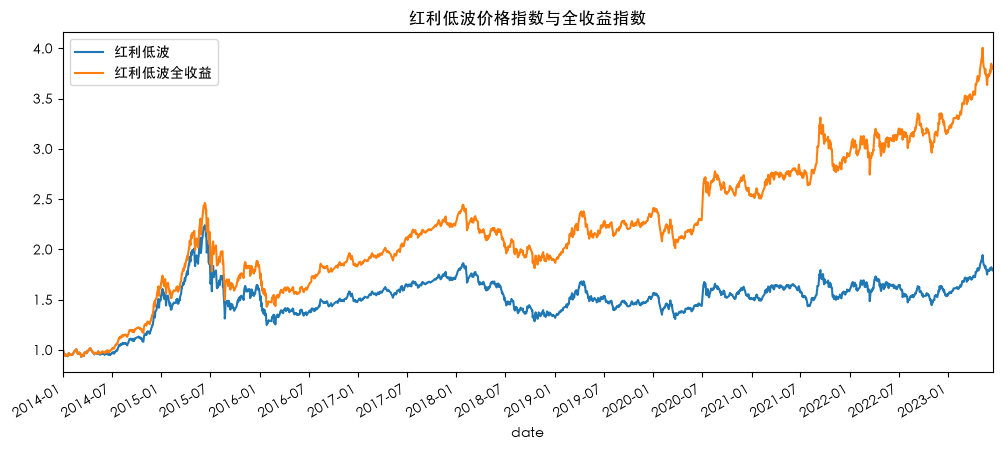

In [ ]:
plot_index = index.loc['2013-12-31':'2023-06-14', ['price_index', 'total_return_index']].rename(
    columns={'price_index': '红利低波', 'total_return_index': '红利低波全收益'}
).join(official_index, how='inner').dropna()
plot_index = plot_index.div(plot_index.iloc[0])
ax = plot_index.plot(figsize=(12, 5), title="红利低波价格指数与全收益指数")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_xlim(pd.Timestamp('2013-12-31'), pd.Timestamp('2023-06-14'))
ax.figure.autofmt_xdate()

## 全收益指数区间图

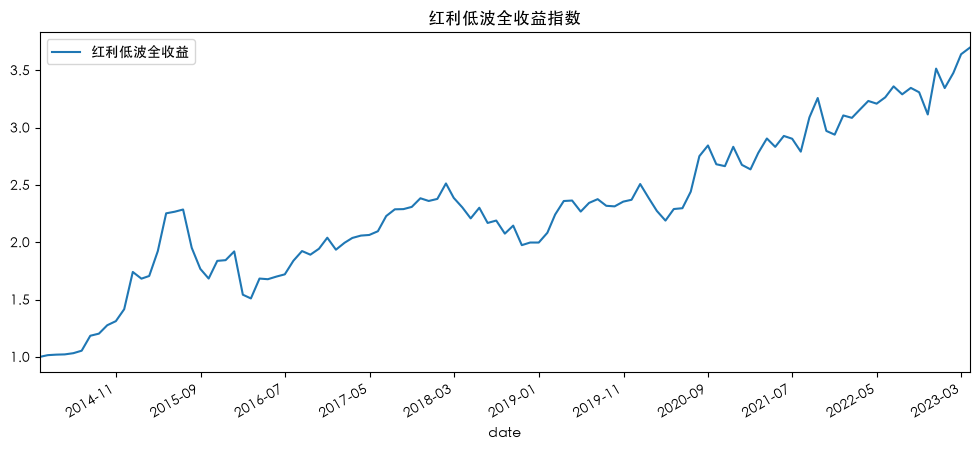

In [15]:
total_return_plot = index.loc['2014-01-30':'2023-03-31', ['total_return_index']].copy()
total_return_plot = pd.concat([total_return_plot.iloc[[0]], total_return_plot.resample('ME').last()])
total_return_plot = total_return_plot[~total_return_plot.index.duplicated()].sort_index()
total_return_plot = total_return_plot.div(total_return_plot.iloc[0])
total_return_plot.columns = ['红利低波全收益']
ax = total_return_plot.plot(figsize=(12, 5), title='红利低波全收益指数')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_xlim(pd.Timestamp('2014-01-30'), pd.Timestamp('2023-03-31'))
ax.figure.autofmt_xdate()